# Prévision scénarisée du risque et de la gravité des collisions routières

## Choisir un jour, des conditions routières et obtenir une estimation du risque ainsi que les localisations les plus probables

<p class="lead">
Ce notebook présente une démarche de science des données visant à transformer un historique de collisions en un jeu de données analytique exploitable pour la prévision. L’objectif n’est pas seulement d’estimer la gravité d’une collision déjà enregistrée, mais de construire une base où chaque observation représente une combinaison <strong>zone géographique + date</strong>. Cette structure permet d’inclure des jours où aucune collision n’a été observée, des jours avec collisions limitées aux dommages matériels et des jours avec collisions associées à des blessures.
</p>

<p class="lead">
À partir de cette base dérivée, le modèle apprend à estimer, pour une zone donnée et pour les sept jours suivant la dernière date disponible dans l’historique, le niveau le plus probable parmi trois classes : aucune collision observée, collision avec dommages matériels, ou collision avec blessures. Les conditions routières et météorologiques peuvent être renseignées pour chaque jour futur afin de simuler différents scénarios de risque.
</p>

<div class="badge-row">
    <span class="badge">Python</span>
    <span class="badge">classification multiclasse</span>
    <span class="badge">données temporelles</span>
    <span class="badge">risque routier</span>
    <span class="badge">science des données appliquée</span>
</div>


<div class="media-frame">
    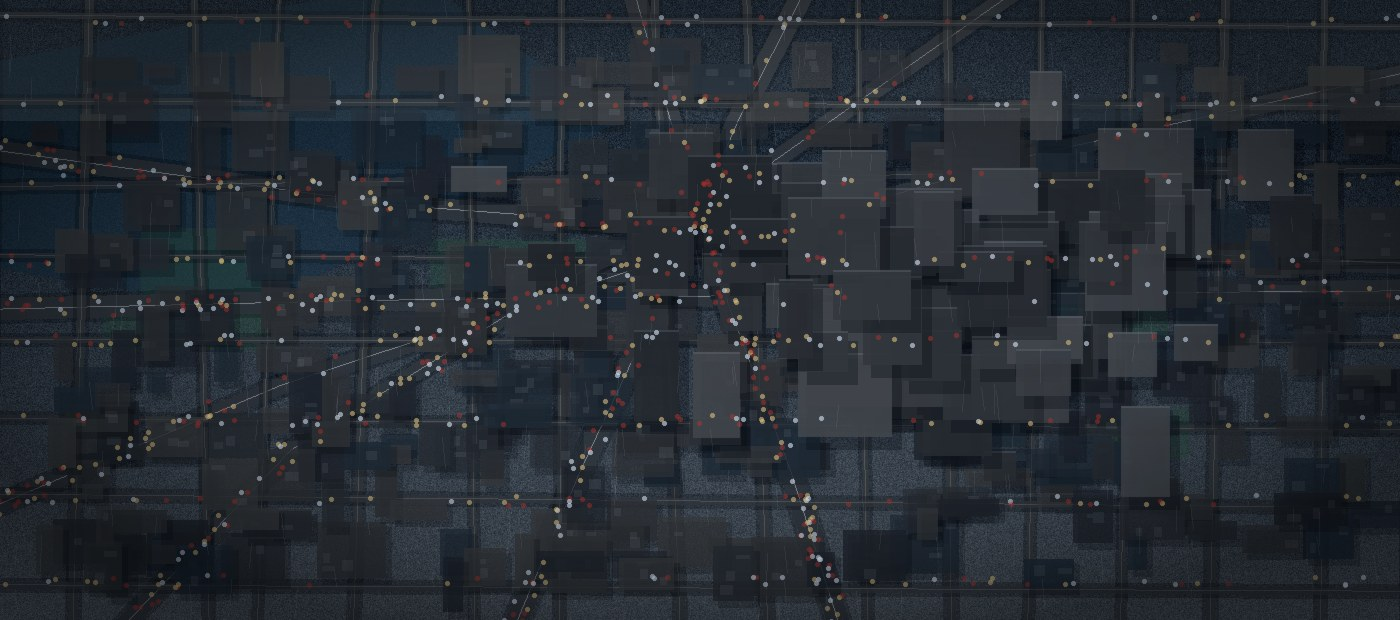
</div>

<div class="caption">
Image générée pour illustrer le contexte analytique : environnement urbain dense, réseaux routiers, circulation et conditions qui peuvent influencer la gravité des collisions. Aucune personne identifiable n’est représentée.
</div>

## 1. Description du projet et objectif

<p class="lead">
L’objectif de ce projet est de transformer l’historique des collisions de Seattle en un jeu de données analytique permettant d’estimer le risque routier dans un contexte donné. Au lieu d’analyser uniquement les accidents déjà enregistrés, le notebook reconstruit une vision plus complète en intégrant aussi des jours et des localisations où aucune collision n’a été observée.
</p>

<p class="lead">
Cette transformation permet de formuler le problème comme une classification à trois classes : <em>aucune collision observée</em>, <em>collision avec dommages matériels seulement</em> et <em>collision avec blessures</em>. Le modèle apprend donc à reconnaître, à partir des données historiques, les contextes qui ressemblent davantage à une situation sans accident, à une collision peu grave ou à une collision plus sévère.
</p>

<p class="lead">
L’utilisateur peut ensuite créer un scénario concret. Par exemple : <em>demain est un mercredi, il pleut, la chaussée est mouillée et la luminosité est faible</em>. À partir de ces conditions, le modèle estime la répartition probable entre les trois classes et fournit une lecture du niveau de risque associé au scénario.
</p>

<p class="lead">
Deux modes d’analyse sont possibles. Si une localisation précise est choisie, le notebook calcule les probabilités estimées pour cette localisation. Si aucune localisation n’est imposée, il compare les principales localisations présentes dans l’historique et retourne les cinq endroits les plus exposés selon les conditions sélectionnées.
</p>

<p class="lead">
Le résultat doit être interprété comme une estimation statistique fondée sur les tendances historiques. Il ne s’agit pas d’une certitude opérationnelle, mais d’un outil d’aide à l’analyse permettant d’identifier les contextes et les zones où le risque estimé est plus élevé.
</p>


| Sortie attendue | Description |
|---|---|
| Probabilité d’aucune collision | Le scénario ressemble davantage à des jours sans accident observé. |
| Probabilité de collision avec dommages matériels | Le scénario ressemble davantage à des jours avec accident sans blessure. |
| Probabilité de collision avec blessures | Le scénario ressemble davantage à des jours avec accident plus grave. |
| Top 5 des localisations | Si aucune localisation n’est choisie, le modèle classe les zones les plus risquées selon le scénario. |
| Gravité conditionnelle | Si l’on suppose qu’une collision se produit, un second modèle estime la gravité probable. |


## 2. Source des données

Le jeu de données utilisé correspond au fichier historique des collisions routières de Seattle diffusé dans le cadre du projet IBM / Cognitive Class :

`Data-Collisions.csv`

Dans ce notebook, seules les colonnes nécessaires à la modélisation sont chargées afin de réduire le temps de traitement. Après le chargement, l’analyse est limitée aux cinq dernières années disponibles dans les données.

| Attribut | Description |
|---|---|
| `SEVERITYCODE` | Code de gravité de la collision. Dans ce projet, `1` correspond à une collision avec dommages matériels seulement et `2` à une collision avec blessures. |
| `INCDATE` / `INCDTTM` | Date, ou date et heure, de l’incident. Ces informations permettent de construire les variables temporelles : jour de semaine, mois, saison et position dans l’année. |
| `LOCATION` | Description textuelle de la zone où la collision a été enregistrée. Elle sert d’approximation de la localisation géographique. |
| `WEATHER` | Conditions météorologiques associées à la collision. |
| `ROADCOND` | État de la chaussée au moment de la collision. |
| `LIGHTCOND` | Conditions de luminosité. |
| `ADDRTYPE` | Type d’adresse : intersection, bloc, etc. |
| `JUNCTIONTYPE` | Type de jonction routière, lorsque disponible. |

<div class="small-note">
Le dataset original contient les collisions enregistrées. Il ne contient pas directement toutes les journées sans accident. Le notebook reconstruit donc ces observations à partir du calendrier et des localisations retenues.
</div>


## 3. Approche de modélisation

La logique du projet repose sur une transformation importante : passer d’un fichier d’événements à une base analytique par zone et par date.

Dans le fichier source, une ligne correspond à une collision. Pour prévoir le risque, il faut aussi représenter les situations où aucune collision n’a été observée. Le notebook construit donc une grille complète de type :

| Localisation | Date | Conditions du scénario | Classe cible |
|---|---|---|---|
| Zone A | Mercredi | pluie, chaussée mouillée | collision avec blessures |
| Zone A | Jeudi | temps clair, chaussée sèche | aucune collision observée |
| Zone B | Mercredi | pluie, chaussée mouillée | dommages matériels seulement |

La variable cible comporte trois classes :

| Classe | Signification |
|---:|---|
| `0` | Aucune collision observée dans la localisation à cette date. |
| `1` | Au moins une collision observée, limitée aux dommages matériels. |
| `2` | Au moins une collision avec blessures observée. |

Deux modèles complémentaires sont utilisés :

| Modèle | Rôle |
|---|---|
| Modèle multiclasse | Estime les probabilités des trois classes : aucune collision, dommages matériels, blessures. |
| Modèle conditionnel de gravité | Estime la gravité probable si l’on suppose qu’une collision se produit. |

<div class="card">
<p class="lead">
La première question est : <em>dans ce contexte, quel est le niveau de risque estimé ?</em> La seconde question est : <em>si une collision se produit, quelle gravité semble la plus probable ?</em>
</p>
</div>


## 4. Installation et importation des bibliothèques

Cette étape prépare l’environnement de travail. Les bibliothèques utilisées servent à charger les données, créer le jeu analytique, entraîner les modèles et évaluer les résultats.

**Ce qui est prévu dans cette étape** : importer les bibliothèques, fixer une graine de reproductibilité et définir la période maximale d’historique conservée.

**Résultat attendu** : l’environnement est prêt pour exécuter les étapes suivantes de façon reproductible.

In [3]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    f1_score
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
MAX_HISTORY_YEARS = 5
TOP_N_LOCATIONS = 50

print("Environnement initialisé.")
print(f"Période maximale utilisée pour l'analyse : {MAX_HISTORY_YEARS} dernières années disponibles.")
print(f"Nombre maximal de localisations retenues : {TOP_N_LOCATIONS}.")

Environnement initialisé.
Période maximale utilisée pour l'analyse : 5 dernières années disponibles.
Nombre maximal de localisations retenues : 50.


## 5. Chargement optimisé des données

Cette étape charge le fichier `Data-Collisions.csv`. Pour améliorer la performance, le notebook ne charge que les colonnes utiles au projet.

**Ce qui est prévu dans cette étape** : lire le fichier local s’il existe, sinon lire l’URL distante, en limitant les colonnes chargées.

**Résultat attendu** : obtenir un DataFrame source contenant uniquement les variables nécessaires à la construction du modèle.

In [4]:
DATA_URL = (
    "https://s3.us.cloud-object-storage.appdomain.cloud/"
    "cf-courses-data/CognitiveClass/DP0701EN/version-2/Data-Collisions.csv"
)
LOCAL_FILE = Path("Data-Collisions.csv")

# Colonnes strictement utiles pour ce notebook.
REQUESTED_COLUMNS = [
    "SEVERITYCODE", "INCDATE", "INCDTTM", "LOCATION",
    "WEATHER", "ROADCOND", "LIGHTCOND", "ADDRTYPE", "JUNCTIONTYPE"
]

source = LOCAL_FILE if LOCAL_FILE.exists() else DATA_URL

try:
    df_raw = pd.read_csv(
        source,
        usecols=lambda col: col in REQUESTED_COLUMNS,
        low_memory=False
    )
except Exception as exc:
    raise RuntimeError(
        "Le jeu de données n'a pas pu être chargé. "
        "Placez Data-Collisions.csv dans le même dossier que ce notebook "
        "ou vérifiez l'accès à Internet."
    ) from exc

print(f"Source utilisée : {source}")
print(f"Colonnes chargées : {list(df_raw.columns)}")
print(f"Dimensions initiales après chargement optimisé : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]:,} colonnes")
df_raw.head()

Source utilisée : https://s3.us.cloud-object-storage.appdomain.cloud/cf-courses-data/CognitiveClass/DP0701EN/version-2/Data-Collisions.csv
Colonnes chargées : ['SEVERITYCODE', 'ADDRTYPE', 'LOCATION', 'INCDATE', 'INCDTTM', 'JUNCTIONTYPE', 'WEATHER', 'ROADCOND', 'LIGHTCOND']
Dimensions initiales après chargement optimisé : 194,673 lignes x 9 colonnes


,SEVERITYCODE,ADDRTYPE,LOCATION,INCDATE,INCDTTM,JUNCTIONTYPE,WEATHER,ROADCOND,LIGHTCOND
0,2,Intersection,5TH AVE NE AND NE 103RD ST,2013/03/27 00:00:00+00,3/27/2013 2:54:00 PM,At Intersection (intersection related),Overcast,Wet,Daylight
1,1,Block,AURORA BR BETWEEN RAYE ST AND BRIDGE WAY N,2006/12/20 00:00:00+00,12/20/2006 6:55:00 PM,Mid-Block (not related to intersection),Raining,Wet,Dark - Street Lights On
2,1,Block,4TH AVE BETWEEN SENECA ST AND UNIVERSITY ST,2004/11/18 00:00:00+00,11/18/2004 10:20:00 AM,Mid-Block (not related to intersection),Overcast,Dry,Daylight
3,1,Block,2ND AVE BETWEEN MARION ST AND MADISON ST,2013/03/29 00:00:00+00,3/29/2013 9:26:00 AM,Mid-Block (not related to intersection),Clear,Dry,Daylight
4,2,Intersection,SWIFT AVE S AND SWIFT AV OFF RP,2004/01/28 00:00:00+00,1/28/2004 8:04:00 AM,At Intersection (intersection related),Raining,Wet,Daylight


## 6. Préparation des données source et filtre sur cinq ans

Cette étape prépare les données avant la construction du jeu analytique.

**Ce qui est prévu dans cette étape** : convertir la date de l’incident, nettoyer les variables catégorielles, conserver uniquement les collisions avec un code de gravité valide et limiter l’analyse aux cinq dernières années disponibles dans le fichier.

**Résultat attendu** : obtenir un historique récent, propre et cohérent, qui servira à reconstruire les observations par zone et par date.

In [5]:
df = df_raw.copy()

# Identification de la colonne de date la plus précise disponible.
date_col = "INCDTTM" if "INCDTTM" in df.columns else "INCDATE"
df["incident_datetime"] = pd.to_datetime(df[date_col], errors="coerce")
df["incident_date"] = df["incident_datetime"].dt.floor("D")

# Colonnes contextuelles utilisées par le projet.
context_cols = ["WEATHER", "ROADCOND", "LIGHTCOND", "ADDRTYPE", "JUNCTIONTYPE"]
for col in context_cols:
    if col not in df.columns:
        df[col] = "Unknown"
    df[col] = df[col].fillna("Unknown").astype(str).str.strip()
    df.loc[df[col].eq(""), col] = "Unknown"

# Gravité.
if "SEVERITYCODE" not in df.columns:
    raise ValueError("La colonne SEVERITYCODE est absente du jeu de données.")

df["severity_code"] = pd.to_numeric(df["SEVERITYCODE"], errors="coerce")

required = ["incident_date", "LOCATION", "severity_code"]
rows_before_cleaning = len(df)
df = df.dropna(subset=required).copy()
df = df[df["severity_code"].isin([1, 2])].copy()
df["LOCATION"] = df["LOCATION"].astype(str).str.strip()
df = df[df["LOCATION"].ne("")].copy()

# Filtre temporel : uniquement les cinq dernières années disponibles dans le dataset.
max_available_date = df["incident_date"].max()
min_allowed_date = max_available_date - pd.DateOffset(years=MAX_HISTORY_YEARS)
rows_before_time_filter = len(df)
df = df[df["incident_date"].ge(min_allowed_date)].copy()

print(f"Colonne de date utilisée : {date_col}")
print(f"Lignes avant nettoyage : {rows_before_cleaning:,}")
print(f"Lignes après nettoyage de base : {rows_before_time_filter:,}")
print(f"Dernière date disponible : {max_available_date.date()}")
print(f"Date minimale conservée : {min_allowed_date.date()}")
print(f"Lignes conservées sur les {MAX_HISTORY_YEARS} dernières années : {len(df):,}")
print(f"Période analysée : {df['incident_date'].min().date()} → {df['incident_date'].max().date()}")

df[["incident_date", "LOCATION", "severity_code"] + context_cols].head()

Colonne de date utilisée : INCDTTM
Lignes avant nettoyage : 194,673
Lignes après nettoyage de base : 191,996
Dernière date disponible : 2020-05-20
Date minimale conservée : 2015-05-20
Lignes conservées sur les 5 dernières années : 52,272
Période analysée : 2015-05-20 → 2020-05-20


,incident_date,LOCATION,severity_code,WEATHER,ROADCOND,LIGHTCOND,ADDRTYPE,JUNCTIONTYPE
5,2019-04-20,24TH AVE NW AND NW 85TH ST,1,Clear,Dry,Daylight,Intersection,At Intersection (intersection related)
7,2020-04-15,BROADWAY AND E PIKE ST,2,Clear,Dry,Daylight,Intersection,At Intersection (intersection related)
15,2020-04-20,9TH AVE BETWEEN LENORA ST AND BLANCHARD ST,1,Unknown,Unknown,Unknown,Block,Driveway Junction
18,2020-04-17,S SPOKANE SR ST BETWEEN 4TH AVE S AND 5TH AVE S,2,Clear,Dry,Daylight,Block,Mid-Block (not related to intersection)
25,2019-04-25,S JACKSON ST BETWEEN 14TH AVE S AND 16TH AVE S,2,Clear,Dry,Daylight,Block,Mid-Block (not related to intersection)


## 7. Construction du jeu de données analytique

Cette étape est le cœur du projet. Le dataset original décrit seulement les collisions enregistrées. Le modèle de prévision a besoin d’une base où les jours sans collision sont également représentés.

**Ce qui est prévu dans cette étape** : sélectionner les localisations les plus fréquentes, créer un calendrier complet pour chaque localisation, et fusionner ce calendrier avec les collisions observées.

**Résultat attendu** : obtenir une base où chaque ligne représente une combinaison `LOCATION + DATE`, avec une classe cible : `0`, `1` ou `2`.

<div class="small-note">
Pour améliorer la performance et limiter les combinaisons peu représentées, le notebook conserve les localisations les plus fréquentes dans les cinq dernières années de l’historique.
</div>

In [8]:
# Fonction de repli si cette cellule est exécutée sans relancer les cellules précédentes.
if "mode_value" not in globals():
    def mode_value(series):
        values = series.dropna()
        if values.empty:
            return "Unknown"
        modes = values.mode()
        return modes.iloc[0] if not modes.empty else "Unknown"

# Localisations les plus représentées dans l'historique récent.
top_locations = df["LOCATION"].value_counts().head(TOP_N_LOCATIONS).index.tolist()
df_loc = df[df["LOCATION"].isin(top_locations)].copy()

# Agrégation des collisions par localisation et par date.
# Une collision avec blessures dans la journée donne la classe 2.
# Sinon, si au moins une collision sans blessure est présente, la classe est 1.
agg_spec = {"severity_code": ["max", "size"]}
for col in context_cols:
    agg_spec[col] = mode_value

accident_daily = df_loc.groupby(["LOCATION", "incident_date"]).agg(agg_spec)
accident_daily.columns = [
    "max_severity" if col == ("severity_code", "max") else
    "collisions_count" if col == ("severity_code", "size") else
    col[0]
    for col in accident_daily.columns
]
accident_daily = accident_daily.reset_index()
accident_daily["target_class"] = np.where(accident_daily["max_severity"].eq(2), 2, 1)

# Calendrier complet : toutes les dates pour toutes les zones retenues.
all_dates = pd.date_range(df["incident_date"].min(), df["incident_date"].max(), freq="D")
grid = pd.MultiIndex.from_product(
    [top_locations, all_dates], names=["LOCATION", "incident_date"]
).to_frame(index=False)

risk_df = grid.merge(
    accident_daily[["LOCATION", "incident_date", "target_class", "collisions_count"] + context_cols],
    on=["LOCATION", "incident_date"],
    how="left"
)

risk_df["target_class"] = risk_df["target_class"].fillna(0).astype(int)
risk_df["collisions_count"] = risk_df["collisions_count"].fillna(0).astype(int)

print(f"Localisations retenues : {len(top_locations)}")
print(f"Nombre de dates conservées : {len(all_dates)}")
print(f"Dimensions du jeu analytique : {risk_df.shape[0]:,} lignes x {risk_df.shape[1]} colonnes")
risk_df[["LOCATION", "incident_date", "target_class", "collisions_count"] + context_cols].head()


Localisations retenues : 50
Nombre de dates conservées : 1828
Dimensions du jeu analytique : 91,400 lignes x 9 colonnes


,LOCATION,incident_date,target_class,collisions_count,WEATHER,ROADCOND,LIGHTCOND,ADDRTYPE,JUNCTIONTYPE
0,6TH AVE AND JAMES ST,2015-05-20,0,0,NaN,NaN,NaN,NaN,NaN
1,6TH AVE AND JAMES ST,2015-05-21,0,0,NaN,NaN,NaN,NaN,NaN
2,6TH AVE AND JAMES ST,2015-05-22,0,0,NaN,NaN,NaN,NaN,NaN
3,6TH AVE AND JAMES ST,2015-05-23,0,0,NaN,NaN,NaN,NaN,NaN
4,6TH AVE AND JAMES ST,2015-05-24,0,0,NaN,NaN,NaN,NaN,NaN


## 8. Conditions routières et météorologiques

Le fichier original contient la météo, l’état de la chaussée et la luminosité uniquement au moment des collisions. Il ne mesure pas directement ces conditions pour les jours sans collision.

**Ce qui est prévu dans cette étape** : conserver les conditions observées pour les jours avec collision et compléter les jours sans collision avec un contexte quotidien approximatif à partir des conditions dominantes observées le même jour dans l’historique de la ville.

**Résultat attendu** : associer à chaque ligne `LOCATION + DATE` un contexte routier et météorologique exploitable par le modèle.

<div class="small-note">
Cette approximation est acceptable pour un prototype pédagogique. Dans un vrai système opérationnel, cette étape devrait être remplacée par des données réelles : météo horaire, trafic, visibilité, événements, travaux et conditions routières par zone.
</div>


In [9]:
# Contexte dominant au niveau de la ville pour chaque date.
city_context = (
    df
    .groupby("incident_date", as_index=False)[context_cols]
    .agg(mode_value)
    .rename(columns={col: f"{col}_city" for col in context_cols})
)

# Fusion du contexte quotidien avec toutes les observations LOCATION + DATE.
risk_df = risk_df.merge(city_context, on="incident_date", how="left")

# Valeurs de repli si certaines dates n'ont pas de contexte disponible.
global_context = {col: mode_value(df[col]) for col in context_cols}
for col in context_cols:
    city_col = f"{col}_city"
    risk_df[col] = risk_df[col].fillna(risk_df[city_col]).fillna(global_context[col])
    risk_df = risk_df.drop(columns=[city_col])

print("Contexte quotidien ajouté au jeu analytique.")
print("Exemple de conditions dominantes utilisées lorsque le contexte direct est absent :")
print(global_context)

risk_df[["LOCATION", "incident_date", "target_class", "collisions_count"] + context_cols].head()


Contexte quotidien ajouté au jeu analytique.
Exemple de conditions dominantes utilisées lorsque le contexte direct est absent :
{'WEATHER': 'Clear', 'ROADCOND': 'Dry', 'LIGHTCOND': 'Daylight', 'ADDRTYPE': 'Block', 'JUNCTIONTYPE': 'Mid-Block (not related to intersection)'}


,LOCATION,incident_date,target_class,collisions_count,WEATHER,ROADCOND,LIGHTCOND,ADDRTYPE,JUNCTIONTYPE
0,6TH AVE AND JAMES ST,2015-05-20,0,0,Clear,Dry,Daylight,Block,Mid-Block (not related to intersection)
1,6TH AVE AND JAMES ST,2015-05-21,0,0,Clear,Dry,Daylight,Block,At Intersection (intersection related)
2,6TH AVE AND JAMES ST,2015-05-22,0,0,Clear,Dry,Daylight,Block,Mid-Block (not related to intersection)
3,6TH AVE AND JAMES ST,2015-05-23,0,0,Clear,Dry,Daylight,Block,Mid-Block (not related to intersection)
4,6TH AVE AND JAMES ST,2015-05-24,0,0,Clear,Dry,Daylight,Block,Mid-Block (not related to intersection)


## 9. Enrichissement temporel

Une date brute n’est pas directement suffisante pour un modèle. Elle doit être transformée en informations interprétables.

**Ce qui est prévu dans cette étape** : extraire le jour de la semaine, le mois, la saison, le statut fin de semaine et une représentation cyclique du jour de l’année.

**Résultat attendu** : ajouter des variables capables de représenter les régularités temporelles, par exemple des différences entre semaine et fin de semaine ou entre saisons.

In [10]:
def season_fr(month):
    if month in [12, 1, 2]:
        return "Hiver"
    if month in [3, 4, 5]:
        return "Printemps"
    if month in [6, 7, 8]:
        return "Été"
    return "Automne"

jour_fr = {
    0: "Lundi", 1: "Mardi", 2: "Mercredi", 3: "Jeudi", 4: "Vendredi", 5: "Samedi", 6: "Dimanche"
}

risk_df["jour_semaine_num"] = risk_df["incident_date"].dt.dayofweek
risk_df["jour_semaine"] = risk_df["jour_semaine_num"].map(jour_fr)
risk_df["mois"] = risk_df["incident_date"].dt.month
risk_df["saison"] = risk_df["mois"].apply(season_fr)
risk_df["weekend"] = risk_df["jour_semaine_num"].isin([5, 6]).astype(int)
risk_df["jour_annee"] = risk_df["incident_date"].dt.dayofyear
risk_df["sin_jour_annee"] = np.sin(2 * np.pi * risk_df["jour_annee"] / 365.25)
risk_df["cos_jour_annee"] = np.cos(2 * np.pi * risk_df["jour_annee"] / 365.25)

class_labels = {
    0: "Aucune collision observée",
    1: "Collision avec dommages matériels",
    2: "Collision avec blessures"
}
risk_df["classe"] = risk_df["target_class"].map(class_labels)

print("Variables temporelles ajoutées : jour de semaine, mois, saison, fin de semaine et cycle annuel.")
risk_df[["incident_date", "jour_semaine", "mois", "saison", "weekend", "classe"]].head()

Variables temporelles ajoutées : jour de semaine, mois, saison, fin de semaine et cycle annuel.


,incident_date,jour_semaine,mois,saison,weekend,classe
0,2015-05-20,Mercredi,5,Printemps,0,Aucune collision observée
1,2015-05-21,Jeudi,5,Printemps,0,Aucune collision observée
2,2015-05-22,Vendredi,5,Printemps,0,Aucune collision observée
3,2015-05-23,Samedi,5,Printemps,1,Aucune collision observée
4,2015-05-24,Dimanche,5,Printemps,1,Aucune collision observée


## 10. Exploration de la variable cible

Avant d’entraîner un modèle, il faut comprendre ce que le modèle doit prédire.

**Ce qui est prévu dans cette étape** : compter le nombre d’observations dans chaque classe cible.

**Résultat attendu** : vérifier si les classes sont équilibrées ou non. Dans ce type de problème, la classe `0` est généralement majoritaire, car une zone donnée n’a pas une collision tous les jours. Cette information guide le choix des métriques d’évaluation.

In [11]:
class_distribution = (
    risk_df["target_class"]
    .value_counts(normalize=False)
    .sort_index()
    .rename(index=class_labels)
    .to_frame("nombre")
)
class_distribution["proportion"] = (class_distribution["nombre"] / class_distribution["nombre"].sum()).round(4)

print("Distribution de la variable cible :")
class_distribution

Distribution de la variable cible :


,nombre,proportion
Aucune collision observée,89201,0.9759
Collision avec dommages matériels,1376,0.0151
Collision avec blessures,823,0.0090


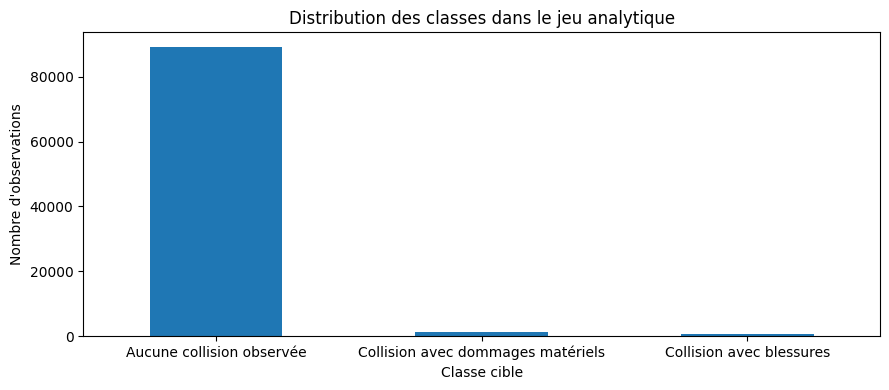

In [12]:
ax = class_distribution["nombre"].plot(kind="bar", figsize=(9, 4), rot=0)
ax.set_title("Distribution des classes dans le jeu analytique")
ax.set_xlabel("Classe cible")
ax.set_ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

## 11. Séparation temporelle entraînement / test

Une séparation aléatoire mélangerait le passé et le futur, ce qui serait moins réaliste pour un projet de prévision.

**Ce qui est prévu dans cette étape** : utiliser les dates les plus anciennes pour entraîner le modèle et les dates les plus récentes pour le tester.

**Résultat attendu** : évaluer le modèle dans une logique proche d’un usage réel : apprendre à partir de l’historique, puis tester sur une période plus récente.

In [13]:
features_cat = ["LOCATION", "jour_semaine", "saison"] + context_cols
features_num = ["mois", "weekend", "jour_annee", "sin_jour_annee", "cos_jour_annee"]
features = features_cat + features_num

dates_sorted = np.array(sorted(risk_df["incident_date"].unique()))
cutoff_date = pd.Timestamp(dates_sorted[int(len(dates_sorted) * 0.80)])

train_mask = risk_df["incident_date"].le(cutoff_date)
test_mask = risk_df["incident_date"].gt(cutoff_date)

X_train = risk_df.loc[train_mask, features]
y_train = risk_df.loc[train_mask, "target_class"]
X_test = risk_df.loc[test_mask, features]
y_test = risk_df.loc[test_mask, "target_class"]

print(f"Période d'entraînement : {risk_df.loc[train_mask, 'incident_date'].min().date()} → {risk_df.loc[train_mask, 'incident_date'].max().date()}")
print(f"Période de test : {risk_df.loc[test_mask, 'incident_date'].min().date()} → {risk_df.loc[test_mask, 'incident_date'].max().date()}")
print(f"Date de coupure : {cutoff_date.date()}")
print(f"Entraînement : {X_train.shape[0]:,} observations")
print(f"Test : {X_test.shape[0]:,} observations")
print(f"Variables utilisées : {len(features)} variables avant encodage")

Période d'entraînement : 2015-05-20 → 2019-05-21
Période de test : 2019-05-22 → 2020-05-20
Date de coupure : 2019-05-21
Entraînement : 73,150 observations
Test : 18,250 observations
Variables utilisées : 13 variables avant encodage


## 12. Entraînement et comparaison des modèles

Cette étape compare plusieurs modèles supervisés adaptés aux données tabulaires.

**Ce qui est prévu dans cette étape** : encoder les variables catégorielles, standardiser les variables numériques et entraîner plusieurs modèles : régression logistique, forêt aléatoire et Extra Trees.

**Résultat attendu** : obtenir un tableau comparatif des modèles, évalués avec des métriques adaptées aux classes déséquilibrées :

- `balanced_accuracy` : mesure la qualité moyenne de prédiction pour chaque classe ;
- `f1_macro` : donne un poids comparable à chaque classe, même si certaines sont rares.

In [14]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=True)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("cat", encoder, features_cat),
        ("num", StandardScaler(), features_num),
    ]
)

models = {
    "Régression logistique équilibrée": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Forêt aléatoire": RandomForestClassifier(
        n_estimators=150,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=150,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

results = []
fitted_models = {}

for name, estimator in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", estimator)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results.append({
        "modèle": name,
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "f1_macro": f1_score(y_test, pred, average="macro")
    })
    fitted_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
print("Comparaison des modèles terminée. Le meilleur modèle est celui qui maximise le f1_macro.")
results_df

Comparaison des modèles terminée. Le meilleur modèle est celui qui maximise le f1_macro.


,modèle,balanced_accuracy,f1_macro
1,Forêt aléatoire,0.484378,0.313632
2,Extra Trees,0.473897,0.310339
0,Régression logistique équilibrée,0.531610,0.295568


## 13. Évaluation du modèle retenu

Le modèle retenu est celui qui obtient le meilleur `f1_macro` sur la période de test.

**Ce qui est prévu dans cette étape** : produire un rapport de classification et une matrice de confusion.

**Résultat attendu** : comprendre les forces et les limites du modèle pour chaque classe : aucune collision, dommages matériels et blessures.

In [15]:
best_name = results_df.iloc[0]["modèle"]
best_model = fitted_models[best_name]

y_pred = best_model.predict(X_test)

print(f"Modèle retenu : {best_name}\n")
print("Rapport de classification sur la période de test :\n")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1, 2],
    target_names=[class_labels[i] for i in [0, 1, 2]],
    zero_division=0
))

Modèle retenu : Forêt aléatoire

Rapport de classification sur la période de test :

                                   precision    recall  f1-score   support

        Aucune collision observée       0.99      0.74      0.85     17915
Collision avec dommages matériels       0.03      0.43      0.05       215
         Collision avec blessures       0.02      0.28      0.04       120

                         accuracy                           0.74     18250
                        macro avg       0.35      0.48      0.31     18250
                     weighted avg       0.97      0.74      0.83     18250



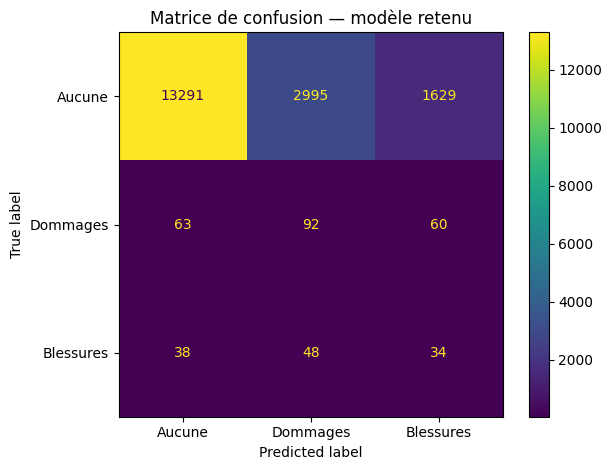

In [16]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Aucune", "Dommages", "Blessures"]
)
disp.plot(values_format="d")
plt.title("Matrice de confusion — modèle retenu")
plt.tight_layout()
plt.show()

## 14. Modèle conditionnel de gravité

Cette étape entraîne un second modèle uniquement sur les jours où une collision a été observée.

**Ce qui est prévu dans cette étape** : filtrer les classes `1` et `2`, entraîner un modèle binaire et estimer la probabilité de blessures si une collision se produit.

**Résultat attendu** : obtenir une probabilité conditionnelle distincte du risque global. Le modèle multiclasse répond à la question « y aura-t-il une collision observée dans ce contexte ? ». Le modèle conditionnel répond à la question « si une collision se produit, quelle gravité est la plus probable ? ».


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Fonction compatible avec plusieurs versions de scikit-learn.
# Dans les versions récentes, OneHotEncoder utilise sparse_output.
# Dans les anciennes versions, il utilise sparse.
def make_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


accident_model_df = risk_df[risk_df["target_class"].isin([1, 2])].copy()

sev_train_mask = accident_model_df["incident_date"].le(cutoff_date)
sev_test_mask = accident_model_df["incident_date"].gt(cutoff_date)

X_sev_train = accident_model_df.loc[sev_train_mask, features]
y_sev_train = accident_model_df.loc[sev_train_mask, "target_class"]

X_sev_test = accident_model_df.loc[sev_test_mask, features]
y_sev_test = accident_model_df.loc[sev_test_mask, "target_class"]

severity_preprocess = ColumnTransformer(
    transformers=[
        ("cat", make_encoder(), features_cat),
        ("num", StandardScaler(), features_num),
    ]
)

severity_model = Pipeline([
    ("preprocess", severity_preprocess),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

severity_model.fit(X_sev_train, y_sev_train)

y_sev_pred = severity_model.predict(X_sev_test)

print("Modèle conditionnel de gravité entraîné.")
print()
print(f"Observations d'entraînement : {X_sev_train.shape[0]:,}")
print(f"Observations de test : {X_sev_test.shape[0]:,}")
print()

print(classification_report(
    y_sev_test,
    y_sev_pred,
    labels=[1, 2],
    target_names=[class_labels[i] for i in [1, 2]],
    zero_division=0
))

Modèle conditionnel de gravité entraîné.

Observations d'entraînement : 1,864
Observations de test : 335

                                   precision    recall  f1-score   support

Collision avec dommages matériels       0.72      0.50      0.59       215
         Collision avec blessures       0.42      0.64      0.51       120

                         accuracy                           0.55       335
                        macro avg       0.57      0.57      0.55       335
                     weighted avg       0.61      0.55      0.56       335



## 15. Valeurs disponibles pour créer un scénario

Cette étape affiche les principales valeurs observées dans les variables catégorielles.

**Ce qui est prévu dans cette étape** : lister les valeurs fréquentes de météo, chaussée, luminosité, type d’adresse et type de jonction.

**Résultat attendu** : permettre à l’utilisateur de remplir le scénario avec des valeurs cohérentes avec le dataset.


In [19]:
def show_top_categories(column, n=10):
    values = df[column].value_counts().head(n)
    return pd.DataFrame({"valeur": values.index, "nombre": values.values})

for col in context_cols:
    print()
    print(f"{col} — valeurs les plus fréquentes")
    display(show_top_categories(col, n=10))



WEATHER — valeurs les plus fréquentes


,valeur,nombre
0,Clear,30421
1,Raining,8637
2,Overcast,6823
3,Unknown,5808
4,Snowing,211
5,Other,163
6,Fog/Smog/Smoke,152
7,Blowing Sand/Dirt,23
8,Sleet/Hail/Freezing Rain,19
9,Severe Crosswind,10



ROADCOND — valeurs les plus fréquentes


,valeur,nombre
0,Dry,33433
1,Wet,12480
2,Unknown,5865
3,Ice,204
4,Snow/Slush,202
5,Other,33
6,Standing Water,25
7,Oil,20
8,Sand/Mud/Dirt,10



LIGHTCOND — valeurs les plus fréquentes


,valeur,nombre
0,Daylight,31284
1,Dark - Street Lights On,12424
2,Unknown,5424
3,Dusk,1518
4,Dawn,783
5,Dark - No Street Lights,452
6,Dark - Street Lights Off,297
7,Other,79
8,Dark - Unknown Lighting,11



ADDRTYPE — valeurs les plus fréquentes


,valeur,nombre
0,Block,33176
1,Intersection,19096



JUNCTIONTYPE — valeurs les plus fréquentes


,valeur,nombre
0,Mid-Block (not related to intersection),25686
1,At Intersection (intersection related),18017
2,Mid-Block (but intersection related),3896
3,Driveway Junction,2136
4,Unknown,1420
5,At Intersection (but not related to intersection),1075
6,Ramp Junction,42


## 16. Création d’un scénario utilisateur

Cette cellule est celle que l’utilisateur modifie pour tester une hypothèse.

**Ce qui est prévu dans cette étape** : choisir un jour, des conditions routières et une localisation optionnelle.

**Résultat attendu** : si `LOCATION = None`, le notebook retourne les cinq localisations les plus probables. Si une localisation précise est indiquée, le notebook retourne la prévision pour cette localisation seulement.

<div class="example-box">
<div class="example-title">Exemple</div>
<p>
Pour simuler « demain est mercredi, il pleut et la chaussée est mouillée », on choisit <code>jour_semaine = "Mercredi"</code>, <code>WEATHER = "Raining"</code> et <code>ROADCOND = "Wet"</code>. La date exacte est construite automatiquement à partir de la dernière date disponible dans l’historique.
</p>
</div>


In [20]:
SCENARIO = {
    # Si date_scenario est None, le notebook cherche la prochaine date correspondant au jour choisi
    # après la dernière date disponible dans l'historique.
    "date_scenario": None,
    "jour_semaine": "Mercredi",

    # Conditions prévues ou simulées.
    "WEATHER": "Raining",
    "ROADCOND": "Wet",
    "LIGHTCOND": "Dark - Street Lights On",
    "ADDRTYPE": "Intersection",
    "JUNCTIONTYPE": "At Intersection (intersection related)",

    # Mettre None pour obtenir les 5 localisations les plus probables.
    # Mettre une valeur exacte de LOCATION pour prédire une seule localisation.
    "LOCATION": None,
    "top_n": 5
}

SCENARIO


{'date_scenario': None,
 'jour_semaine': 'Mercredi',
 'WEATHER': 'Raining',
 'ROADCOND': 'Wet',
 'LIGHTCOND': 'Dark - Street Lights On',
 'ADDRTYPE': 'Intersection',
 'JUNCTIONTYPE': 'At Intersection (intersection related)',
 'LOCATION': None,
 'top_n': 5}

## 17. Fonctions de prévision du scénario

Cette étape transforme le scénario utilisateur en données compatibles avec les modèles.

**Ce qui est prévu dans cette étape** : construire la date du scénario, préparer une ligne par localisation, calculer les variables temporelles, appliquer le modèle multiclasse et le modèle conditionnel de gravité.

**Résultat attendu** : obtenir une table de prévision avec les probabilités pour les trois classes et, si aucune localisation n’est imposée, le Top 5 des localisations.


In [21]:
jour_to_num = {v.lower(): k for k, v in jour_fr.items()}

def prochaine_date_pour_jour(nom_jour, date_reference=None):
    # Retourne la prochaine date correspondant au jour choisi après la date de référence.
    if date_reference is None:
        date_reference = risk_df["incident_date"].max()
    date_reference = pd.Timestamp(date_reference)

    jour_normalise = str(nom_jour).strip().lower()
    if jour_normalise not in jour_to_num:
        valeurs = ", ".join(jour_fr.values())
        raise ValueError(f"Jour invalide : {nom_jour}. Valeurs possibles : {valeurs}")

    cible = jour_to_num[jour_normalise]
    start = date_reference + pd.Timedelta(days=1)
    delta = (cible - start.dayofweek) % 7
    return start + pd.Timedelta(days=int(delta))


def construire_scenario(scenario):
    # Construit les lignes de scénario pour une ou plusieurs localisations.
    scenario = scenario.copy()

    if scenario.get("date_scenario") is not None:
        date_scenario = pd.Timestamp(scenario["date_scenario"])
    else:
        date_scenario = prochaine_date_pour_jour(scenario.get("jour_semaine", "Mercredi"))

    selected_location = scenario.get("LOCATION")
    if selected_location is None:
        locations = top_locations
    else:
        if selected_location not in top_locations:
            raise ValueError(
                "La localisation choisie n'est pas dans les localisations retenues. "
                "Utilisez une valeur exacte de top_locations ou laissez LOCATION = None."
            )
        locations = [selected_location]

    data = pd.DataFrame({
        "LOCATION": locations,
        "incident_date": date_scenario
    })

    for col in context_cols:
        data[col] = scenario.get(col, global_context.get(col, "Unknown"))

    data = add_temporal_features(data)
    return data


def ajouter_probabilites(model, data):
    # Ajoute les probabilités du modèle pour les classes 0, 1 et 2.
    proba = model.predict_proba(data[features])
    classes_model = list(model.classes_)
    out = data.copy()

    for cls in [0, 1, 2]:
        if cls in classes_model:
            out[f"proba_{cls}"] = proba[:, classes_model.index(cls)]
        else:
            out[f"proba_{cls}"] = 0.0
    return out


def predire_scenario(scenario, top_n=5):
    # Prédit le risque global et la gravité conditionnelle pour un scénario utilisateur.
    scenario_rows = construire_scenario(scenario)

    results = ajouter_probabilites(best_model, scenario_rows)
    results["proba_aucune_collision"] = results["proba_0"]
    results["proba_dommages_materiels"] = results["proba_1"]
    results["proba_blessures"] = results["proba_2"]
    results["proba_accident"] = results["proba_1"] + results["proba_2"]
    results["classe_prédite"] = best_model.predict(scenario_rows[features])
    results["interprétation"] = results["classe_prédite"].map(class_labels)

    # Gravité conditionnelle : seulement si une collision est supposée.
    sev_proba = severity_model.predict_proba(scenario_rows[features])
    sev_classes = list(severity_model.classes_)
    results["proba_blessures_si_accident"] = (
        sev_proba[:, sev_classes.index(2)] if 2 in sev_classes else 0.0
    )
    results["gravité_conditionnelle"] = severity_model.predict(scenario_rows[features])
    results["interprétation_gravité_conditionnelle"] = results["gravité_conditionnelle"].map(class_labels)

    cols = [
        "incident_date", "jour_semaine", "LOCATION",
        "WEATHER", "ROADCOND", "LIGHTCOND", "ADDRTYPE", "JUNCTIONTYPE",
        "proba_aucune_collision", "proba_dommages_materiels", "proba_blessures",
        "proba_accident", "proba_blessures_si_accident",
        "interprétation", "interprétation_gravité_conditionnelle"
    ]

    display_df = results[cols].copy()
    prob_cols = [c for c in display_df.columns if c.startswith("proba_")]
    display_df[prob_cols] = display_df[prob_cols].round(3)

    if scenario.get("LOCATION") is None:
        display_df = display_df.sort_values(
            ["proba_accident", "proba_blessures"],
            ascending=False
        ).head(top_n)

    return display_df.reset_index(drop=True)


## 18. Prévision du scénario et Top 5 des localisations

Cette étape applique le scénario au modèle.

**Ce qui est prévu dans cette étape** : si aucune localisation n’est fournie, le notebook teste toutes les localisations retenues et retourne les cinq plus probables.

**Résultat attendu** : obtenir les localisations où le scénario semble historiquement le plus associé à une collision, avec la probabilité de gravité correspondante.


In [25]:
def add_temporal_features(data):
    """
    Ajoute les variables temporelles utilisées par le modèle à partir de la date.

    Cette fonction doit reproduire exactement les mêmes variables temporelles
    que celles utilisées pendant l'entraînement du modèle :
    - jour de la semaine ;
    - mois ;
    - saison ;
    - fin de semaine ;
    - jour de l'année ;
    - représentation cyclique du jour de l'année.
    """
    data = data.copy()

    # Sécurise la présence de la colonne incident_date.
    if "incident_date" not in data.columns:
        if "date" in data.columns:
            data["incident_date"] = data["date"]
        else:
            data["incident_date"] = pd.Timestamp.today().normalize()

    data["incident_date"] = pd.to_datetime(data["incident_date"], errors="coerce")
    data["incident_date"] = data["incident_date"].fillna(pd.Timestamp.today().normalize())

    jours_fr = {
        0: "Lundi",
        1: "Mardi",
        2: "Mercredi",
        3: "Jeudi",
        4: "Vendredi",
        5: "Samedi",
        6: "Dimanche"
    }

    def determiner_saison(mois):
        if mois in [12, 1, 2]:
            return "Hiver"
        elif mois in [3, 4, 5]:
            return "Printemps"
        elif mois in [6, 7, 8]:
            return "Été"
        else:
            return "Automne"

    # Variables calendaires simples.
    data["jour_semaine_num"] = data["incident_date"].dt.dayofweek
    data["jour_semaine"] = data["jour_semaine_num"].map(jours_fr)
    data["mois"] = data["incident_date"].dt.month
    data["saison"] = data["mois"].apply(determiner_saison)
    data["weekend"] = data["jour_semaine_num"].isin([5, 6]).astype(int)

    # Variables cycliques.
    # Elles permettent au modèle de comprendre que le 31 décembre et le 1er janvier
    # sont proches dans le calendrier, même si leurs numéros de jour sont éloignés.
    data["jour_annee"] = data["incident_date"].dt.dayofyear
    data["sin_jour_annee"] = np.sin(2 * np.pi * data["jour_annee"] / 365.25)
    data["cos_jour_annee"] = np.cos(2 * np.pi * data["jour_annee"] / 365.25)

    return data

In [26]:
scenario_result = predire_scenario(SCENARIO, top_n=SCENARIO.get("top_n", 5))
scenario_result


,incident_date,jour_semaine,LOCATION,WEATHER,ROADCOND,LIGHTCOND,ADDRTYPE,JUNCTIONTYPE,proba_aucune_collision,proba_dommages_materiels,proba_blessures,proba_accident,proba_blessures_si_accident,interprétation,interprétation_gravité_conditionnelle
0,2020-05-27,Mercredi,CORSON AVE S AND S MICHIGAN ST,Raining,Wet,Dark - Street Lights On,Intersection,At Intersection (intersection related),0.058,0.505,0.438,0.942,0.612,Collision avec dommages matériels,Collision avec blessures
1,2020-05-27,Mercredi,6TH AVE AND JAMES ST,Raining,Wet,Dark - Street Lights On,Intersection,At Intersection (intersection related),0.059,0.536,0.405,0.941,0.579,Collision avec dommages matériels,Collision avec blessures
2,2020-05-27,Mercredi,BOREN AVE AND PIKE ST,Raining,Wet,Dark - Street Lights On,Intersection,At Intersection (intersection related),0.063,0.395,0.543,0.937,0.696,Collision avec blessures,Collision avec blessures
3,2020-05-27,Mercredi,BROADWAY E AND E OLIVE WAY,Raining,Wet,Dark - Street Lights On,Intersection,At Intersection (intersection related),0.073,0.519,0.408,0.927,0.456,Collision avec dommages matériels,Collision avec dommages matériels
4,2020-05-27,Mercredi,5TH AVE AND UNIVERSITY ST,Raining,Wet,Dark - Street Lights On,Intersection,At Intersection (intersection related),0.073,0.531,0.397,0.927,0.555,Collision avec dommages matériels,Collision avec blessures


## 19. Visualisation du scénario

Cette étape représente graphiquement les probabilités estimées pour les localisations retournées.

**Ce qui est prévu dans cette étape** : comparer la probabilité globale d’accident, la probabilité de blessures dans le modèle global et la probabilité de blessures si un accident se produit.

**Résultat attendu** : identifier rapidement les localisations qui ressortent le plus fortement dans le scénario choisi.


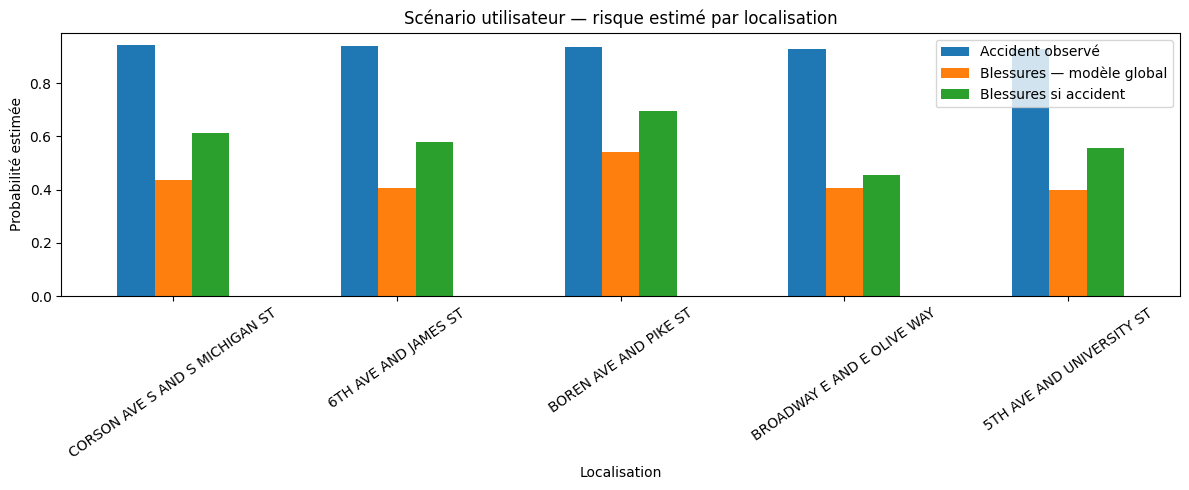

In [27]:
plot_df = scenario_result.copy()
plot_df["libellé"] = plot_df["LOCATION"].str.slice(0, 55)

ax = plot_df.set_index("libellé")[["proba_accident", "proba_blessures", "proba_blessures_si_accident"]].plot(
    kind="bar",
    figsize=(12, 5),
    rot=35
)
ax.set_title("Scénario utilisateur — risque estimé par localisation")
ax.set_xlabel("Localisation")
ax.set_ylabel("Probabilité estimée")
ax.legend([
    "Accident observé",
    "Blessures — modèle global",
    "Blessures si accident"
], loc="upper right")
plt.tight_layout()
plt.show()


## 20. Prévision pour une localisation précise

Cette étape montre comment tester une seule localisation.

**Ce qui est prévu dans cette étape** : reprendre le scénario précédent et imposer une localisation précise.

**Résultat attendu** : obtenir une prévision détaillée pour une seule zone, avec la classe prédite et la gravité conditionnelle.


In [28]:
# Exemple : tester la localisation la plus probable retournée par le Top 5.
scenario_location = SCENARIO.copy()
scenario_location["LOCATION"] = scenario_result.loc[0, "LOCATION"]

predire_scenario(scenario_location, top_n=1)


,incident_date,jour_semaine,LOCATION,WEATHER,ROADCOND,LIGHTCOND,ADDRTYPE,JUNCTIONTYPE,proba_aucune_collision,proba_dommages_materiels,proba_blessures,proba_accident,proba_blessures_si_accident,interprétation,interprétation_gravité_conditionnelle
0,2020-05-27,Mercredi,CORSON AVE S AND S MICHIGAN ST,Raining,Wet,Dark - Street Lights On,Intersection,At Intersection (intersection related),0.058,0.505,0.438,0.942,0.612,Collision avec dommages matériels,Collision avec blessures


## 21. Comment interpréter les résultats

Le modèle retourne plusieurs probabilités, qui répondent à des questions différentes.

| Colonne | Interprétation |
|---|---|
| `proba_aucune_collision` | Le scénario ressemble à des jours sans collision observée dans cette localisation. |
| `proba_dommages_materiels` | Le scénario ressemble à des jours avec collision limitée aux dommages matériels. |
| `proba_blessures` | Le scénario ressemble à des jours avec collision impliquant des blessures. |
| `proba_accident` | Somme des probabilités des classes `1` et `2`. Elle représente le risque estimé d’avoir une collision observée. |
| `proba_blessures_si_accident` | Probabilité conditionnelle de blessures si l’on suppose qu’une collision se produit. |

<div class="example-box">
<div class="example-title">Lecture pratique</div>
<p>
Si le modèle retourne une probabilité d’accident élevée pour une localisation donnée, cela ne signifie pas qu’un accident va nécessairement se produire. Cela signifie que, selon l’historique analysé, le scénario ressemble à des situations où une collision a été observée plus souvent que dans d’autres localisations.
</p>
<p>
Si la probabilité de blessures conditionnelle est élevée, cela signifie que, parmi les collisions historiques similaires, les cas avec blessures sont plus représentés que les collisions avec dommages matériels seulement.
</p>
</div>


## 22. Limites et améliorations professionnelles

Ce notebook construit une approche cohérente à partir du dataset historique disponible. Toutefois, certaines limites doivent être clairement reconnues.

| Limite | Impact |
|---|---|
| Les jours sans collision sont reconstruits | Ils sont dérivés du calendrier et non directement observés comme événements indépendants. |
| La météo des jours sans collision est approximée | Le dataset ne fournit pas de météo réelle pour les jours sans accident. |
| `LOCATION` est textuelle | La localisation n’est pas une coordonnée géographique précise. |
| Pas de trafic réel | Le modèle ne connaît pas le volume de véhicules, les vitesses ni la congestion. |
| Probabilités non calibrées | Les valeurs doivent être interprétées comme des estimations de modèle, pas comme des probabilités opérationnelles certifiées. |

Pour faire évoluer ce prototype vers un système plus robuste, il faudrait ajouter :

| Donnée complémentaire | Apport attendu |
|---|---|
| Météo horaire réelle et prévisionnelle | Conditions futures plus fiables. |
| Données de trafic | Mesure de l’exposition au risque : volume, vitesse, congestion. |
| Coordonnées géographiques | Modélisation spatiale plus précise. |
| Travaux, événements, fermeture de voies | Meilleure explication des pics de risque. |
| Calibration probabiliste | Probabilités plus interprétables en production. |


## 23. Conclusion

Ce notebook met en place une approche plus proche d’un vrai cas d’usage prédictif. L’utilisateur peut choisir un jour, des conditions météorologiques et routières, avec ou sans localisation précise. Le modèle produit ensuite une estimation du risque global, de la gravité probable et, lorsque la localisation n’est pas imposée, les cinq zones les plus susceptibles d’être associées à une collision dans ce scénario.

La valeur principale du projet réside dans la construction du nouveau jeu analytique. Le dataset initial décrit uniquement des accidents enregistrés. Le notebook le transforme en une base `localisation + date`, capable de représenter aussi les jours sans collision observée. Cette transformation rend possible une modélisation à trois classes : aucune collision, dommages matériels ou blessures.

L’approche reste un prototype, mais elle respecte une logique professionnelle : définition de l’unité d’analyse, construction de la cible, filtre temporel, séparation passé/futur, comparaison de modèles, interprétation des probabilités et explicitation des limites.
